In [1]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import joblib
import json
import re


In [2]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")
FOLDER_TMP      = os.getenv("FOLDER_TMP")

SEED            = int(os.getenv("SEED"))

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

🔌 [OK] Conexión establecida con TimescaleDB.


In [3]:
SQL='select * from vectores'
df = pd.read_sql(SQL, engine)


In [4]:
lista_label = df['label'].unique().tolist()

In [5]:
len(lista_label)

54

In [6]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()
df_result['split_type'] = 'unknown'

In [7]:
df_result

,vector_id,execution_name,label,split_type
0,90244,light-oauth2-data-1719592986.tar,correct,unknown
1,90245,light-oauth2-data-1719592986.tar,correct,unknown
2,90246,light-oauth2-data-1719592986.tar,correct,unknown
3,90247,light-oauth2-data-1719592986.tar,correct,unknown
4,90333,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400,unknown
...,...,...,...,...
90185,180429,light-oauth2-data-1725866154.tar,delete_user_404_no_user,unknown
90186,180430,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,unknown
90187,180431,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,unknown
90188,180432,light-oauth2-data-1725866154.tar,update_password_400_not_match,unknown


In [8]:
filename = f'{FOLDER_SALIDA}/lista_metric_name_vector.json'

with open(filename, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

# <span style="color:#2ca02c">1. Separamos conjuntos de train, val y test</span>

<span style="color:#2ca02c">Por cada label dividimos los datos en train, val y test</span>


In [9]:
dic_idx_train = {}
dic_idx_resto = {}
dic_idx_val   = {}
dic_idx_test  = {}

In [10]:
for label in lista_label:
    indices = df[ df['label']== label ].index.values
    idx_train, idx_resto = train_test_split(indices   , test_size=0.4 , random_state=SEED)
    idx_val,   idx_test  = train_test_split(idx_resto , test_size=0.5 , random_state=SEED)
    df_result.loc[idx_train , 'split_type'] = 'train'
    df_result.loc[idx_val   , 'split_type'] = 'val'
    df_result.loc[idx_test  , 'split_type'] = 'test'
    dic_idx_train[label] = idx_train
    dic_idx_resto[label] = idx_resto
    dic_idx_val[label]   = idx_val
    dic_idx_test[label]  = idx_test

df_reparto = pd.DataFrame({
    'Cantidad': df_result['split_type'].value_counts(),
    'Porcentaje (%)': (df_result['split_type'].value_counts(normalize=True) * 100).round(2)
})

print("Reparto porcentual de los datos:")
display(df_reparto)

Reparto porcentual de los datos:


,Cantidad,Porcentaje (%)
split_type,,
train,54093,59.98
test,18058,20.02
val,18039,20.00


In [11]:
df_result

,vector_id,execution_name,label,split_type
0,90244,light-oauth2-data-1719592986.tar,correct,test
1,90245,light-oauth2-data-1719592986.tar,correct,train
2,90246,light-oauth2-data-1719592986.tar,correct,train
3,90247,light-oauth2-data-1719592986.tar,correct,test
4,90333,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400,train
...,...,...,...,...
90185,180429,light-oauth2-data-1725866154.tar,delete_user_404_no_user,train
90186,180430,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,val
90187,180431,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,train
90188,180432,light-oauth2-data-1725866154.tar,update_password_400_not_match,val


<span style="color:#2ca02c"> Convetimos los vectores del df en una matriz, seran los datos que pasemos a los algoritmo   </span>


In [12]:
X_matrix = np.array(df['vector'].tolist())
X_matrix.shape

(90190, 354)

# <span style="color:#2ca02c">2. Usamos Isolation Forest (IF) para identificar anomalias</span>

<span style="color:#2ca02c"> Entrenamos IF con los datos del split 'train' y label 'correct'   </span>


In [13]:
idx_correct_train = dic_idx_train['correct']
idx_correct_val   = dic_idx_val['correct']
idx_correct_test  = dic_idx_test['correct']

In [14]:
N_datos_test_por_anomalia = int( len(idx_correct_test)  / (len(lista_label)-1) )

In [15]:
idx_test =idx_correct_test.copy()
for label in lista_label:
    if label=='correct':
        continue
    if len(dic_idx_test[label])<N_datos_test_por_anomalia:
        idx_test = np.concatenate((idx_test, dic_idx_test[label]))
    else:
        #idx_test.extend(dic_idx_test[label][:N_datos_test_por_anomalia])
        # Corrección: pon los dos arrays dentro de un paréntesis
        idx_test = np.concatenate((idx_test, dic_idx_test[label][:N_datos_test_por_anomalia]))
        
X_test  = X_matrix[idx_test]

In [16]:
len(idx_correct_train)

10231

In [17]:
idx_correct_val

array([65461, 62557, 89796, ..., 31467, 42793, 37650], shape=(3410,))

In [18]:
idx_correct_test

array([54453, 70322, 76171, ...,  5440, 50166, 71891], shape=(3411,))

In [19]:
X_matrix.shape

(90190, 354)

In [20]:
X_correct_train = X_matrix[idx_correct_train]
X_correct_test  = X_matrix[idx_correct_test]

In [21]:
idx_correct_test.shape

(3411,)

In [22]:
 df.loc[idx_correct_test].shape

(3411, 5)

In [23]:
df.shape

(90190, 5)

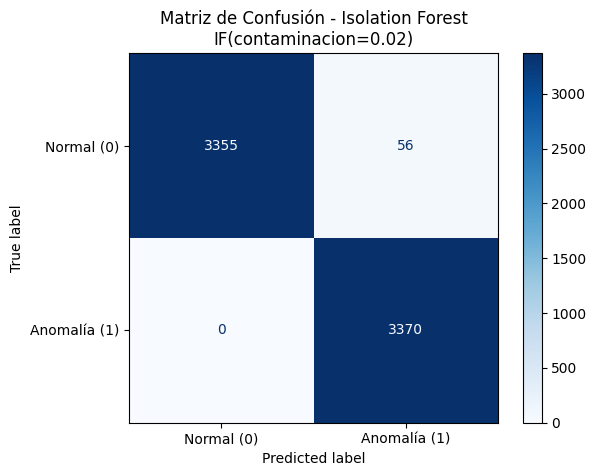

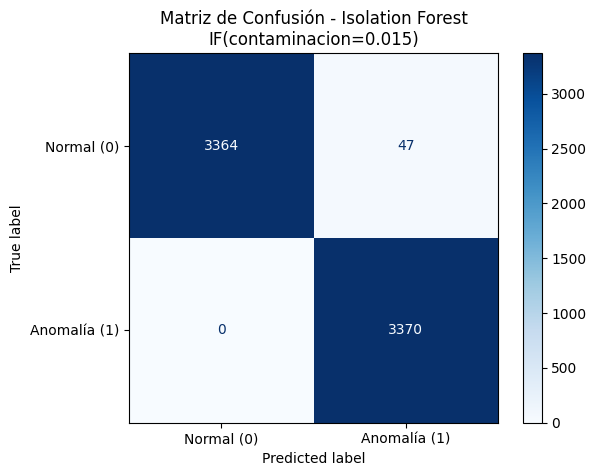

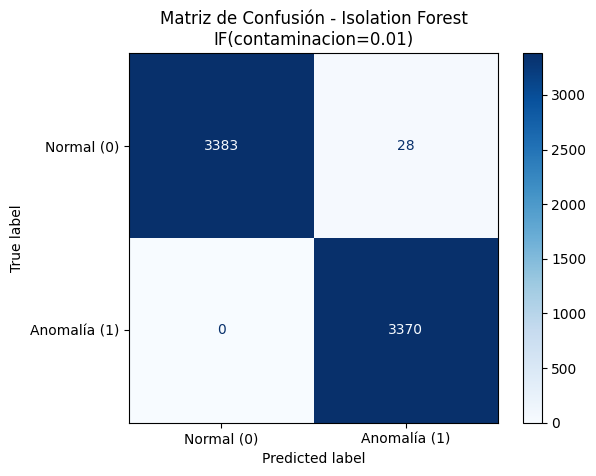

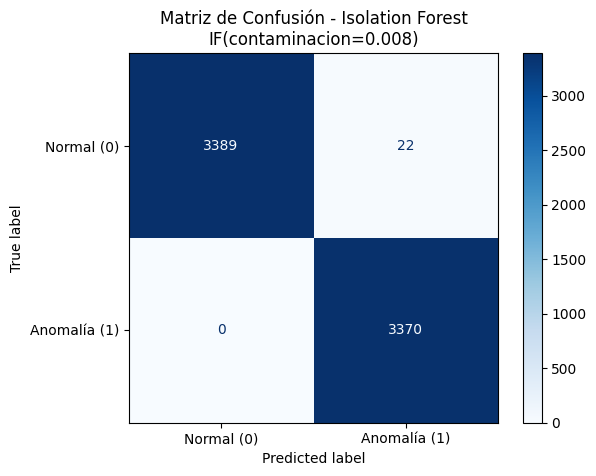

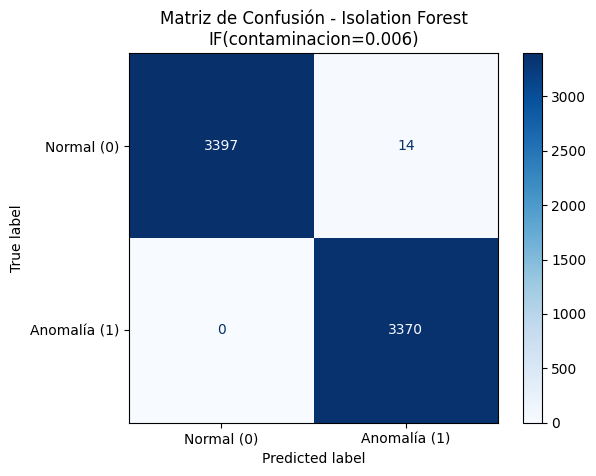

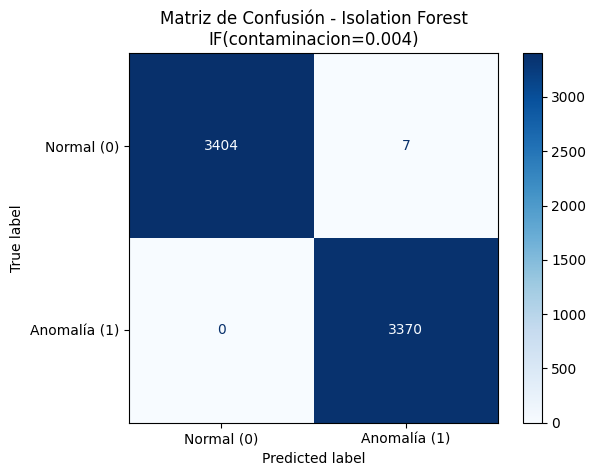

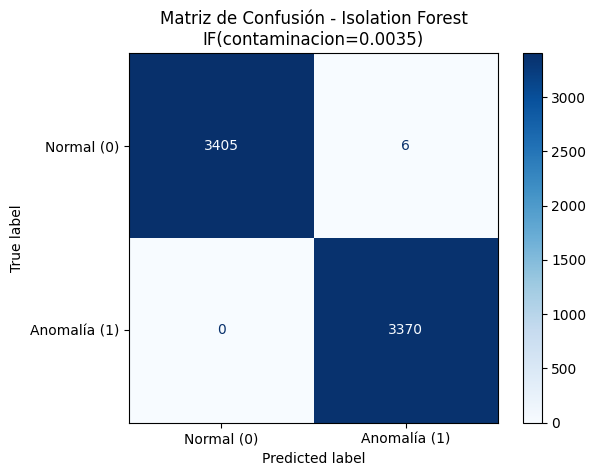

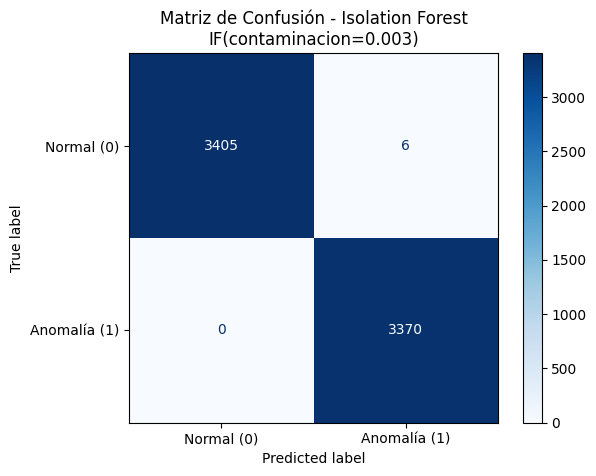

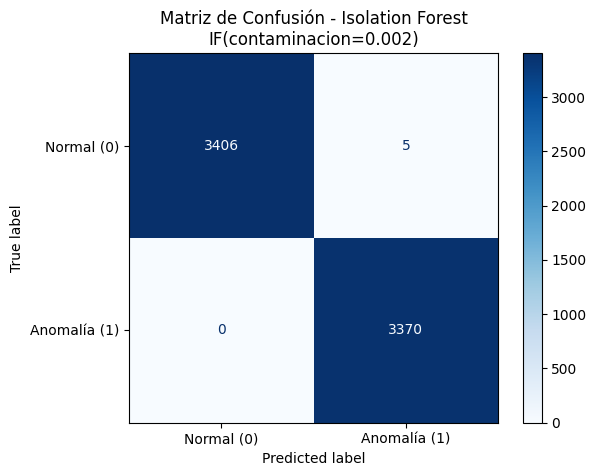

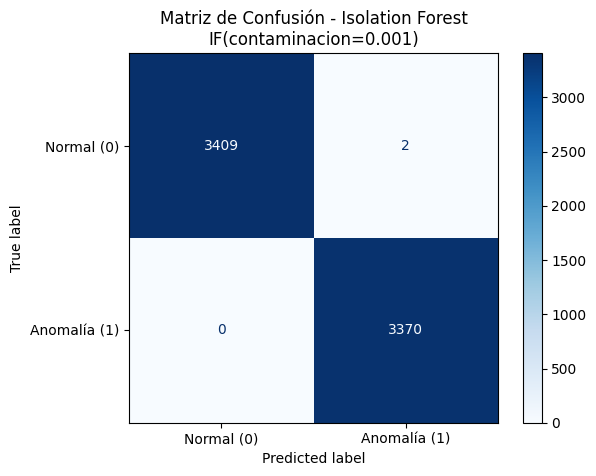

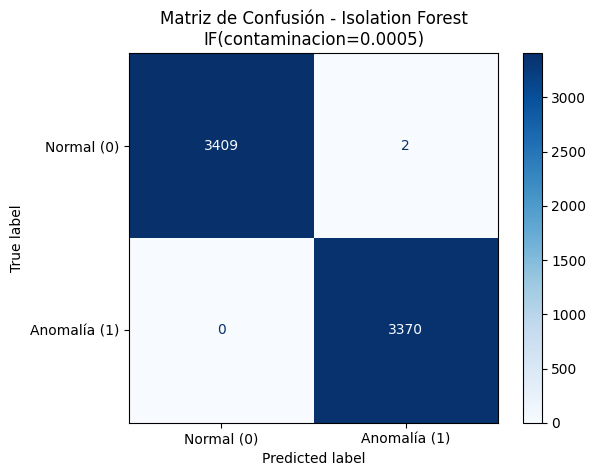

In [24]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_correct_test, 'execution_name'],
    'label': df.loc[idx_test, 'label']
})

N = 0
lista_result=[]
for contaminacion in [0.02, 0.015, 0.01, 0.008, 0.006, 0.004, 0.0035, 0.003, 0.002, 0.001, 0.0005]:
    N += 1
    model = IsolationForest(
        n_estimators=200, 
        max_samples='auto', 
        contamination=contaminacion, 
        random_state=SEED
    )
    model.fit(X_correct_train)
    scores = model.decision_function(X_test)
    Y_pred = model.predict(X_test)

    model_name = f'IF(contaminacion={contaminacion})'
    joblib.dump(model, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    

    df_result[f'result_({model_name})'] = float('nan')
    df_result[f'scores_({model_name})'] = float('nan')
    df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
    df_result.loc[idx_test, f'scores_({model_name})'] = scores
    
    # Mapeo: Anomalía (-1) pasa a ser la clase positiva (1) para las métricas, 
    # y lo normal ('correct' / 1) pasa a ser la negativa (0 o -1 dependiendo del enfoque).
    # Usaremos 1 para Anomalía (Positivo) y 0 para Normal (Negativo) para facilitar scikit-learn.
    y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    y_pred = df_result.loc[idx_test, f'result_({model_name})'].apply(lambda x: 0 if x == 1 else 1)
    
    # 1. Componentes de la matriz de confusión (con anomalía = positivo = 1)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # 2. Cálculo de métricas
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)         # Sensibilidad / True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0          # True Negative Rate
    f1 = f1_score(y_true, y_pred, zero_division=0)

    parametros={'contaminacion':contaminacion}
    # 3. Guardar en un diccionario de registro
    reg_resultado_algoritmo = {

        'test_name': model_name,
        'parametros': json.dumps(parametros),
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1)
    }
    lista_result.append(reg_resultado_algoritmo)
    
    # 4. Visualizarla (Opcional: puedes comentar el show si son muchas iteraciones)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión - Isolation Forest\n{model_name}')
    plt.show()

# Convertir la lista de registros en un DataFrame global para revisarlos cómodamente
df_anomaly_detection_summary = pd.DataFrame(lista_result)

In [25]:
df_anomaly_detection_summary.to_parquet(f'{FOLDER_SALIDA}/df_anomaly_detection_IF_summary.parquet', index=False,engine='fastparquet')

In [26]:
df_anomaly_detection_summary

,test_name,parametros,TP,FP,TN,FN,accuracy,precision,recall,specificity,f1_score
0,IF(contaminacion=0.02),"{""contaminacion"": 0.02}",3370,56,3355,0,0.991742,0.983654,1.0,0.983583,0.991760
1,IF(contaminacion=0.015),"{""contaminacion"": 0.015}",3370,47,3364,0,0.993069,0.986245,1.0,0.986221,0.993075
2,IF(contaminacion=0.01),"{""contaminacion"": 0.01}",3370,28,3383,0,0.995871,0.991760,1.0,0.991791,0.995863
3,IF(contaminacion=0.008),"{""contaminacion"": 0.008}",3370,22,3389,0,0.996756,0.993514,1.0,0.993550,0.996747
4,IF(contaminacion=0.006),"{""contaminacion"": 0.006}",3370,14,3397,0,0.997935,0.995863,1.0,0.995896,0.997927
5,IF(contaminacion=0.004),"{""contaminacion"": 0.004}",3370,7,3404,0,0.998968,0.997927,1.0,0.997948,0.998963
6,IF(contaminacion=0.0035),"{""contaminacion"": 0.0035}",3370,6,3405,0,0.999115,0.998223,1.0,0.998241,0.999111
7,IF(contaminacion=0.003),"{""contaminacion"": 0.003}",3370,6,3405,0,0.999115,0.998223,1.0,0.998241,0.999111
8,IF(contaminacion=0.002),"{""contaminacion"": 0.002}",3370,5,3406,0,0.999263,0.998519,1.0,0.998534,0.999259
9,IF(contaminacion=0.001),"{""contaminacion"": 0.001}",3370,2,3409,0,0.999705,0.999407,1.0,0.999414,0.999703


In [27]:
model = joblib.load(f'{FOLDER_SALIDA}/models/IF(contaminacion=0.0005).joblib')

Y_test = df_result.loc[idx_test, 'label'].apply(lambda x: 1 if x == 'correct' else -1)

result = permutation_importance(
    model, X_test, Y_test, 
    scoring='f1',
    n_repeats=10, 
    random_state=SEED, 
    n_jobs=-1
)

# Creamos el DataFrame de importancia
df_importancia = pd.DataFrame({
    'Caracteristica': lista_metric_name_vector,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=False)

print(df_importancia.head(10))

                                        Caracteristica  Importancia
353                     scrape_series_added_mod(lag_2)          0.0
334       prometheus_tsdb_head_active_appenders(lag_2)          0.0
333  prometheus_target_interval_length_seconds_sum_...          0.0
332  prometheus_target_interval_length_seconds_coun...          0.0
331   prometheus_target_interval_length_seconds(lag_2)          0.0
329  prometheus_remote_storage_highest_timestamp_in...          0.0
328  prometheus_http_response_size_bytes_sum_diff(l...          0.0
327  prometheus_http_response_size_bytes_count_diff...          0.0
326  prometheus_http_response_size_bytes_bucket_dif...          0.0
325  prometheus_http_request_duration_seconds_sum_d...          0.0


In [28]:
df_importancia.shape

(354, 2)

In [29]:
with pd.option_context('display.max_rows', None):
    display(df_importancia)
print(df_importancia[df_importancia['Importancia']<0].shape)
lista_features_poco_importantes=df_importancia[df_importancia['Importancia']<0]['Caracteristica'].tolist()
lista_features_poco_importantes = [re.sub(r'\s*\(.*?\)', '', cadena) for cadena in lista_features_poco_importantes]
lista_features_poco_importantes = list(set(lista_features_poco_importantes))
print(len(lista_features_poco_importantes))

,Caracteristica,Importancia
353,scrape_series_added_mod(lag_2),0.000000
334,prometheus_tsdb_head_active_appenders(lag_2),0.000000
333,prometheus_target_interval_length_seconds_sum_...,0.000000
332,prometheus_target_interval_length_seconds_coun...,0.000000
331,prometheus_target_interval_length_seconds(lag_2),0.000000
329,prometheus_remote_storage_highest_timestamp_in...,0.000000
328,prometheus_http_response_size_bytes_sum_diff(l...,0.000000
327,prometheus_http_response_size_bytes_count_diff...,0.000000
326,prometheus_http_response_size_bytes_bucket_dif...,0.000000
325,prometheus_http_request_duration_seconds_sum_d...,0.000000


(61, 2)
40


In [31]:
lista_metric_name_vector
lista_metric_name_reducida_IF=[]
lista_idx_reducida_IF=[]
ID=0
for metric_name in lista_metric_name_vector:
    DESCARTAR=False
    for metric_name_poco_importante in lista_features_poco_importantes:
        if metric_name.find(metric_name_poco_importante)>=0:
            DESCARTAR=True
            break
    if not DESCARTAR:
        lista_metric_name_reducida_IF.append(metric_name)
        lista_idx_reducida_IF.append(ID)
    ID+=1
        
        




In [32]:
len(lista_metric_name_reducida_IF)

222

In [33]:
X_matrix_reducida      = X_matrix[:, lista_idx_reducida_IF]
X_correct_train        = X_matrix_reducida[idx_correct_train]
X_test                 = X_matrix_reducida[idx_test]

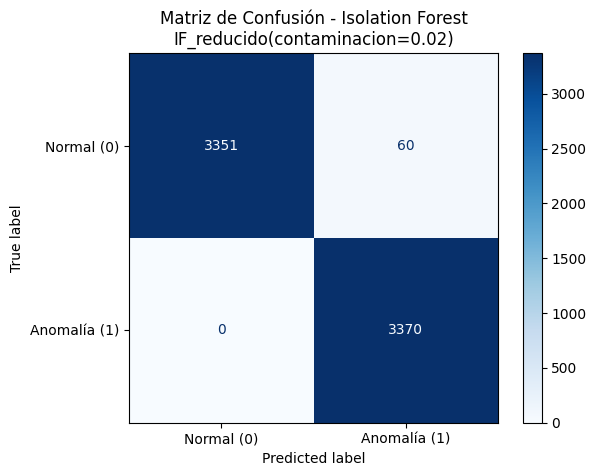

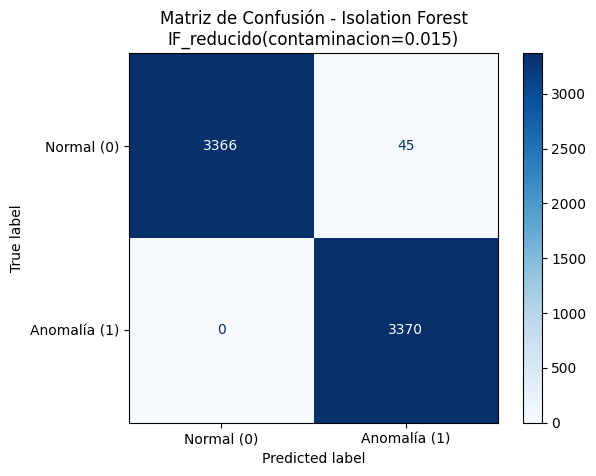

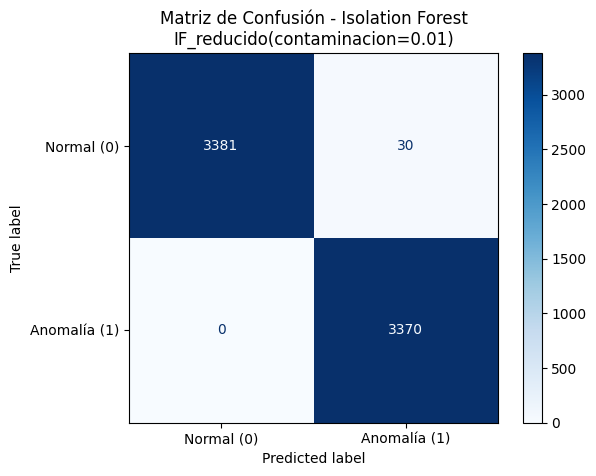

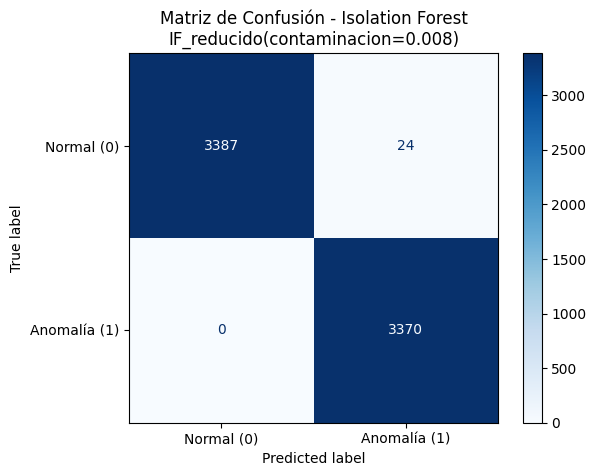

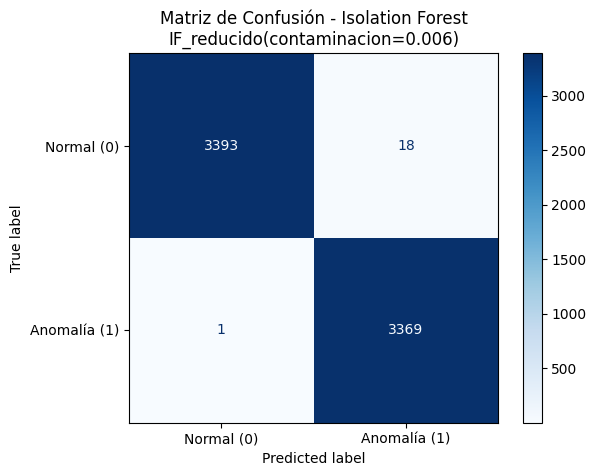

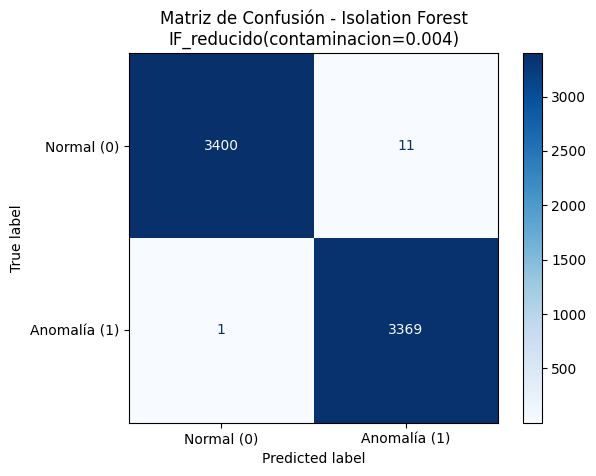

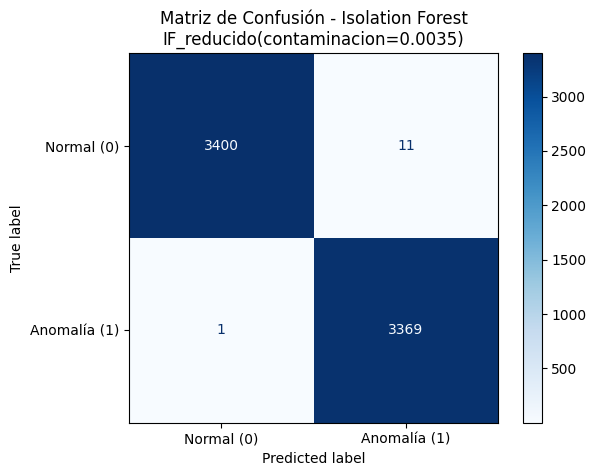

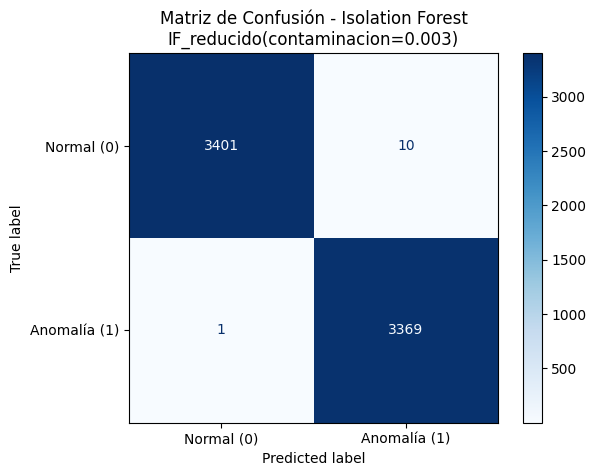

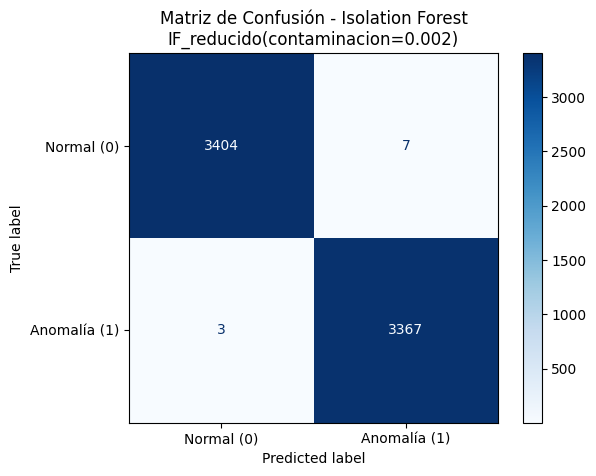

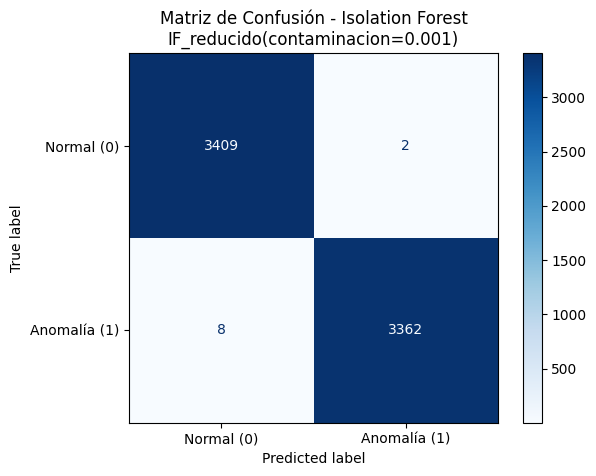

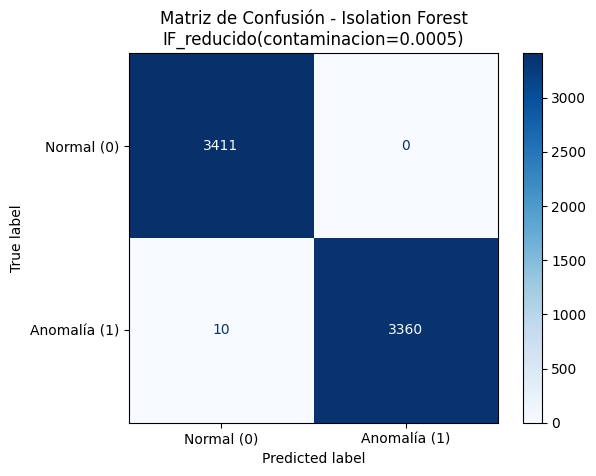

In [34]:
for contaminacion in [0.02, 0.015, 0.01, 0.008, 0.006, 0.004, 0.0035, 0.003, 0.002, 0.001, 0.0005]:
    N += 1
    model = IsolationForest(
        n_estimators=200, 
        max_samples='auto', 
        contamination=contaminacion, 
        random_state=SEED
    )
    model.fit(X_correct_train)
    scores = model.decision_function(X_test)
    Y_pred = model.predict(X_test)

    model_name = f'IF_reducido(contaminacion={contaminacion})'
    joblib.dump(model, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    

    df_result[f'result_({model_name})'] = float('nan')
    df_result[f'scores_({model_name})'] = float('nan')
    df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
    df_result.loc[idx_test, f'scores_({model_name})'] = scores
    
    # Mapeo: Anomalía (-1) pasa a ser la clase positiva (1) para las métricas, 
    # y lo normal ('correct' / 1) pasa a ser la negativa (0 o -1 dependiendo del enfoque).
    # Usaremos 1 para Anomalía (Positivo) y 0 para Normal (Negativo) para facilitar scikit-learn.
    y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    y_pred = df_result.loc[idx_test, f'result_({model_name})'].apply(lambda x: 0 if x == 1 else 1)
    
    # 1. Componentes de la matriz de confusión (con anomalía = positivo = 1)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # 2. Cálculo de métricas
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)         # Sensibilidad / True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0          # True Negative Rate
    f1 = f1_score(y_true, y_pred, zero_division=0)

    parametros={'contaminacion':contaminacion}
    # 3. Guardar en un diccionario de registro
    reg_resultado_algoritmo = {

        'test_name': model_name,
        'parametros': json.dumps(parametros),
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1)
    }
    lista_result.append(reg_resultado_algoritmo)
    
    # 4. Visualizarla (Opcional: puedes comentar el show si son muchas iteraciones)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión - Isolation Forest\n{model_name}')
    plt.show()

# Convertir la lista de registros en un DataFrame global para revisarlos cómodamente
df_anomaly_detection_summary = pd.DataFrame(lista_result)

In [35]:
df_anomaly_detection_summary

,test_name,parametros,TP,FP,TN,FN,accuracy,precision,recall,specificity,f1_score
0,IF(contaminacion=0.02),"{""contaminacion"": 0.02}",3370,56,3355,0,0.991742,0.983654,1.000000,0.983583,0.991760
1,IF(contaminacion=0.015),"{""contaminacion"": 0.015}",3370,47,3364,0,0.993069,0.986245,1.000000,0.986221,0.993075
2,IF(contaminacion=0.01),"{""contaminacion"": 0.01}",3370,28,3383,0,0.995871,0.991760,1.000000,0.991791,0.995863
3,IF(contaminacion=0.008),"{""contaminacion"": 0.008}",3370,22,3389,0,0.996756,0.993514,1.000000,0.993550,0.996747
4,IF(contaminacion=0.006),"{""contaminacion"": 0.006}",3370,14,3397,0,0.997935,0.995863,1.000000,0.995896,0.997927
5,IF(contaminacion=0.004),"{""contaminacion"": 0.004}",3370,7,3404,0,0.998968,0.997927,1.000000,0.997948,0.998963
6,IF(contaminacion=0.0035),"{""contaminacion"": 0.0035}",3370,6,3405,0,0.999115,0.998223,1.000000,0.998241,0.999111
7,IF(contaminacion=0.003),"{""contaminacion"": 0.003}",3370,6,3405,0,0.999115,0.998223,1.000000,0.998241,0.999111
8,IF(contaminacion=0.002),"{""contaminacion"": 0.002}",3370,5,3406,0,0.999263,0.998519,1.000000,0.998534,0.999259
9,IF(contaminacion=0.001),"{""contaminacion"": 0.001}",3370,2,3409,0,0.999705,0.999407,1.000000,0.999414,0.999703


In [ ]:
df_anomaly_detection_summary.to_parquet(f'{FOLDER_SALIDA}/df_anomaly_detection_IF_summary.parquet', index=False,engine='fastparquet')

# <span style="color:#2ca02c">3. Usamos Isolation Forest (IF) clasififar anomalias</span>

<span style="color:#2ca02c">Crearemos un modelo IF entrenado con datos de anomalia, para clasificar primero se aplciara el detector de anomalia y luego aplica los detectores individuales para cada anomalia</span>

{'test_name': 'IF(label=invalid_code_verifier_format_PKCE_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 79, 'FP': 39, 'TN': 236, 'FN': 233, 'accuracy': 0.5366269165247018, 'precision': 0.6694915254237288, 'recall': 0.2532051282051282, 'specificity': 0.8581818181818182, 'f1_score': 0.3674418604651163}


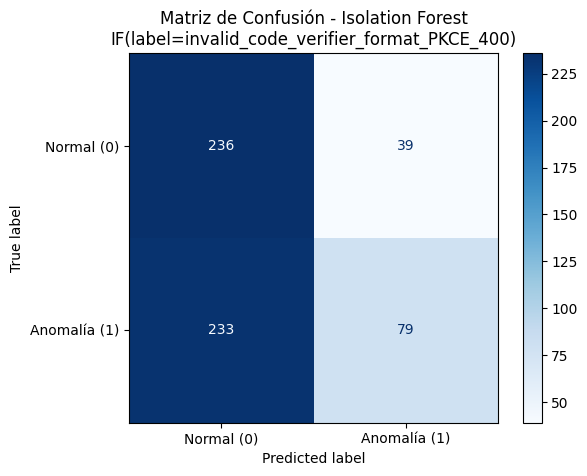

{'test_name': 'IF(label=code_verifier_too_long_pkce_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 87, 'FP': 28, 'TN': 233, 'FN': 225, 'accuracy': 0.5584642233856894, 'precision': 0.7565217391304347, 'recall': 0.27884615384615385, 'specificity': 0.89272030651341, 'f1_score': 0.40749414519906324}


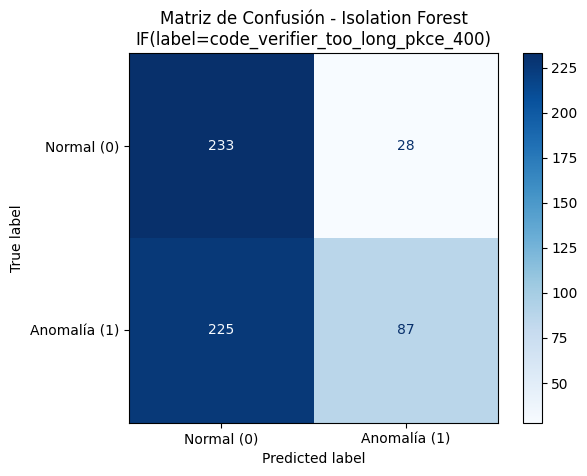

{'test_name': 'IF(label=code_verifier_missing_pkce_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 94, 'FP': 23, 'TN': 250, 'FN': 218, 'accuracy': 0.588034188034188, 'precision': 0.8034188034188035, 'recall': 0.30128205128205127, 'specificity': 0.9157509157509157, 'f1_score': 0.4382284382284382}


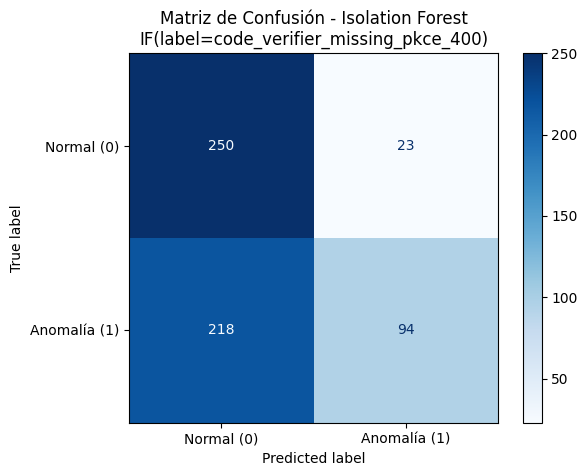

{'test_name': 'IF(label=verification_failed_pkce_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 87, 'FP': 34, 'TN': 256, 'FN': 225, 'accuracy': 0.5697674418604651, 'precision': 0.71900826446281, 'recall': 0.27884615384615385, 'specificity': 0.8827586206896552, 'f1_score': 0.4018475750577367}


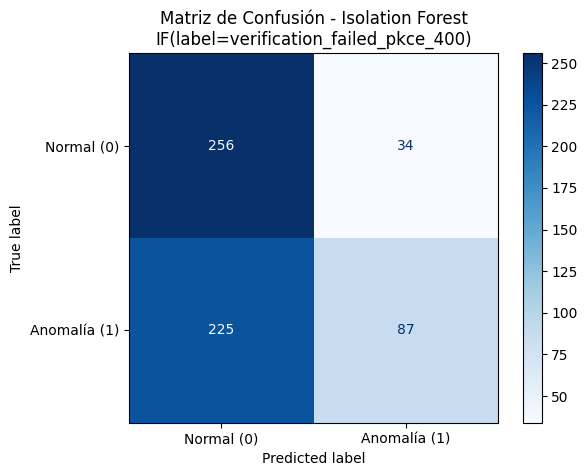

{'test_name': 'IF(label=authorization_code_client_id_missing_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 94, 'FP': 25, 'TN': 257, 'FN': 218, 'accuracy': 0.5909090909090909, 'precision': 0.7899159663865546, 'recall': 0.30128205128205127, 'specificity': 0.9113475177304965, 'f1_score': 0.4361948955916473}


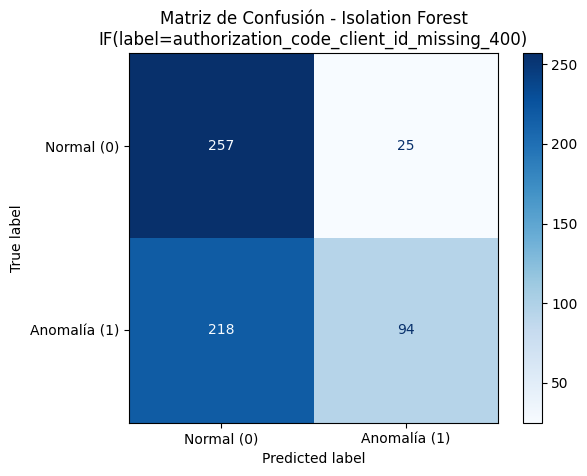

{'test_name': 'IF(label=update_user_404_no_user)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 96, 'FP': 23, 'TN': 257, 'FN': 216, 'accuracy': 0.5962837837837838, 'precision': 0.8067226890756303, 'recall': 0.3076923076923077, 'specificity': 0.9178571428571428, 'f1_score': 0.44547563805104406}


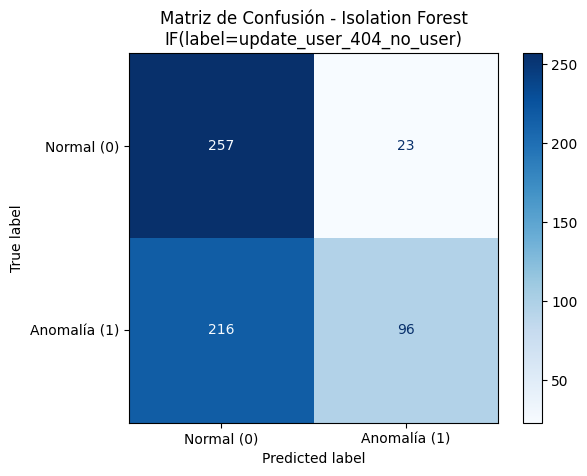

{'test_name': 'IF(label=update_password_404_user_not_found)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 71, 'FP': 44, 'TN': 216, 'FN': 241, 'accuracy': 0.5017482517482518, 'precision': 0.6173913043478261, 'recall': 0.22756410256410256, 'specificity': 0.8307692307692308, 'f1_score': 0.3325526932084309}


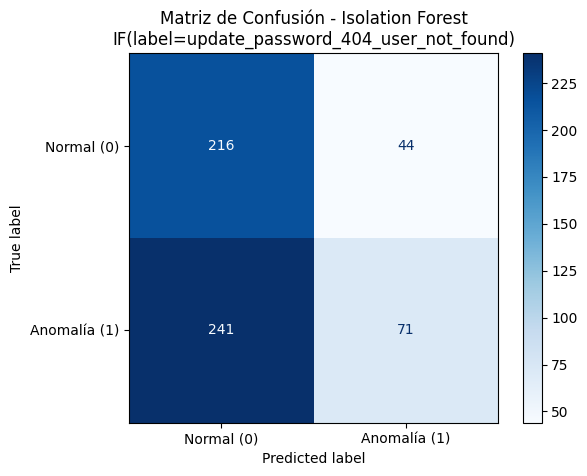

{'test_name': 'IF(label=update_password_400_not_match)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 203, 'FP': 20, 'TN': 522, 'FN': 369, 'accuracy': 0.6508078994614004, 'precision': 0.9103139013452914, 'recall': 0.3548951048951049, 'specificity': 0.9630996309963099, 'f1_score': 0.5106918238993711}


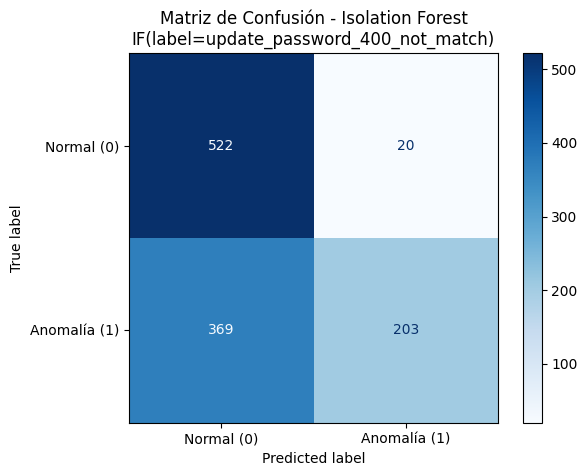

{'test_name': 'IF(label=access_token_client_secret_wrong_401)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 98, 'FP': 22, 'TN': 265, 'FN': 214, 'accuracy': 0.6060100166944908, 'precision': 0.8166666666666667, 'recall': 0.3141025641025641, 'specificity': 0.9233449477351916, 'f1_score': 0.4537037037037037}


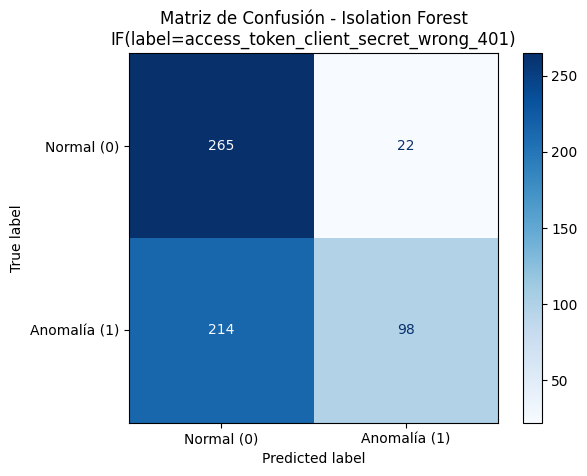

{'test_name': 'IF(label=register_client_400_clientType)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 123, 'FP': 0, 'TN': 302, 'FN': 189, 'accuracy': 0.6921824104234527, 'precision': 1.0, 'recall': 0.3942307692307692, 'specificity': 1.0, 'f1_score': 0.5655172413793104}


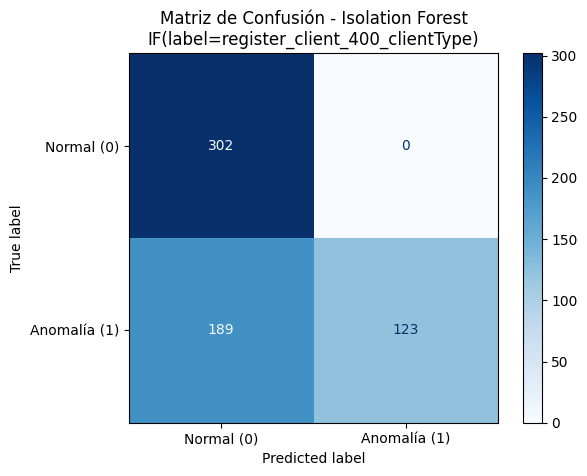

{'test_name': 'IF(label=register_client_404_no_user)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 141, 'FP': 0, 'TN': 340, 'FN': 223, 'accuracy': 0.6832386363636364, 'precision': 1.0, 'recall': 0.3873626373626374, 'specificity': 1.0, 'f1_score': 0.5584158415841585}


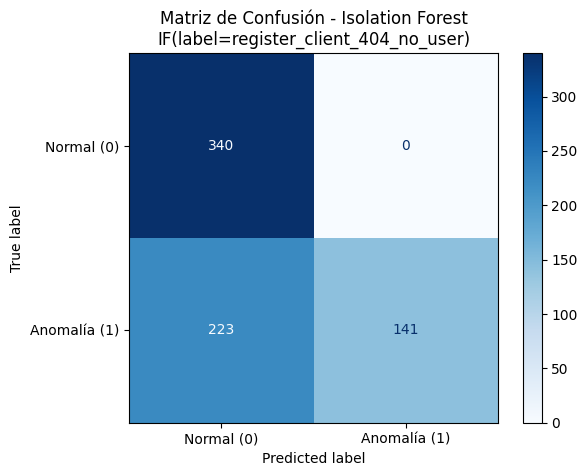

{'test_name': 'IF(label=update_client_400_clientProfile)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 117, 'FP': 2, 'TN': 280, 'FN': 195, 'accuracy': 0.6683501683501684, 'precision': 0.9831932773109243, 'recall': 0.375, 'specificity': 0.9929078014184397, 'f1_score': 0.54292343387471}


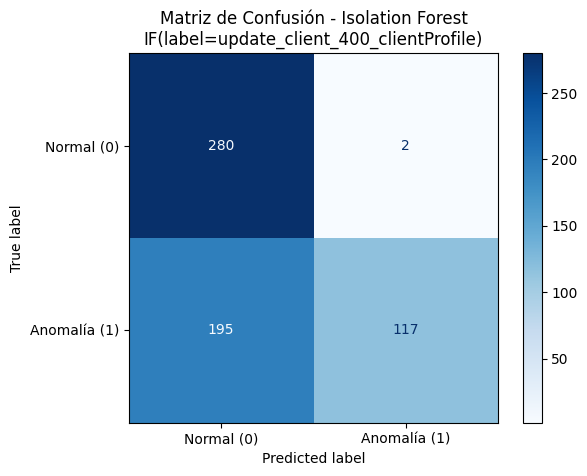

{'test_name': 'IF(label=update_client_404_ownerId)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 136, 'FP': 4, 'TN': 331, 'FN': 228, 'accuracy': 0.6680972818311874, 'precision': 0.9714285714285714, 'recall': 0.37362637362637363, 'specificity': 0.9880597014925373, 'f1_score': 0.5396825396825397}


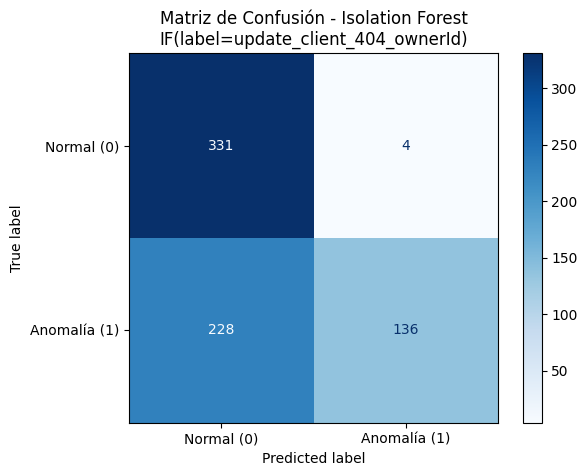

{'test_name': 'IF(label=get_user_404_no_user)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 89, 'FP': 29, 'TN': 248, 'FN': 223, 'accuracy': 0.5721561969439728, 'precision': 0.7542372881355932, 'recall': 0.28525641025641024, 'specificity': 0.8953068592057761, 'f1_score': 0.413953488372093}


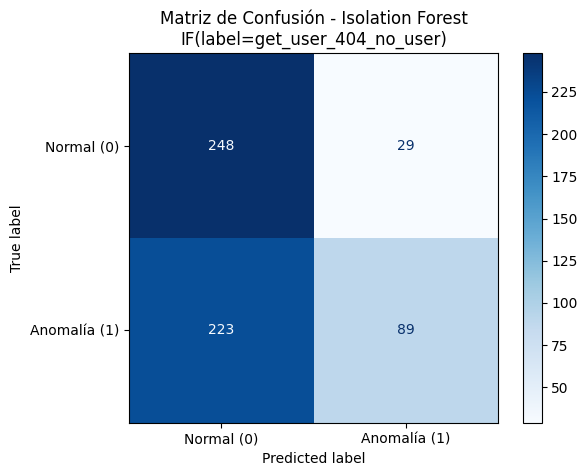

{'test_name': 'IF(label=delete_client_404_no_client)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 90, 'FP': 6, 'TN': 211, 'FN': 170, 'accuracy': 0.6310272536687631, 'precision': 0.9375, 'recall': 0.34615384615384615, 'specificity': 0.9723502304147466, 'f1_score': 0.5056179775280899}


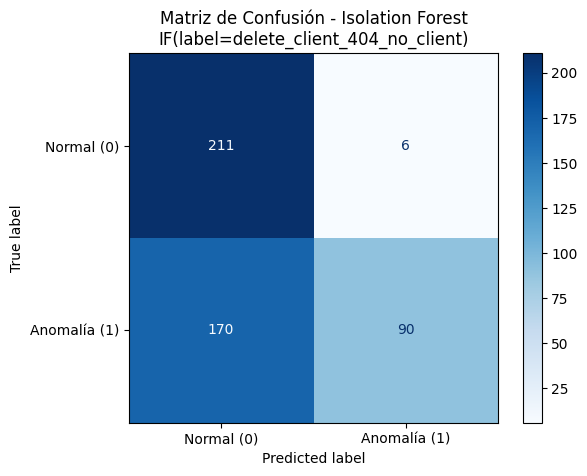

{'test_name': 'IF(label=get_client_404_no_client)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 130, 'FP': 9, 'TN': 319, 'FN': 234, 'accuracy': 0.6488439306358381, 'precision': 0.935251798561151, 'recall': 0.35714285714285715, 'specificity': 0.9725609756097561, 'f1_score': 0.5168986083499006}


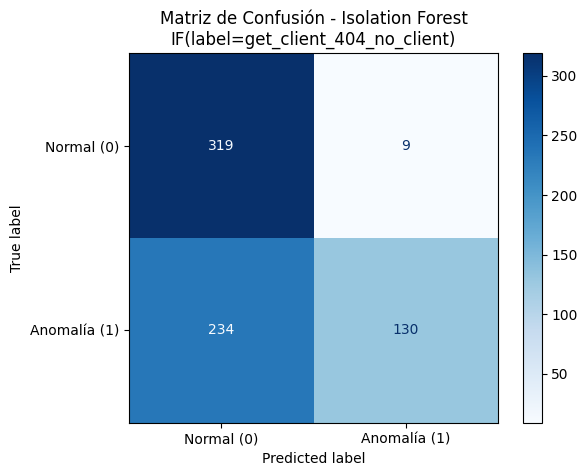

{'test_name': 'IF(label=get_client_page_400_no_page)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 91, 'FP': 9, 'TN': 229, 'FN': 169, 'accuracy': 0.642570281124498, 'precision': 0.91, 'recall': 0.35, 'specificity': 0.9621848739495799, 'f1_score': 0.5055555555555555}


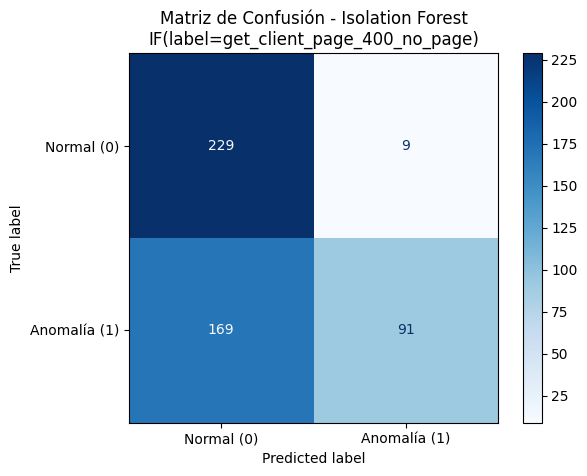

{'test_name': 'IF(label=register_service_400_service_type)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 103, 'FP': 17, 'TN': 269, 'FN': 209, 'accuracy': 0.6220735785953178, 'precision': 0.8583333333333333, 'recall': 0.3301282051282051, 'specificity': 0.9405594405594405, 'f1_score': 0.47685185185185186}


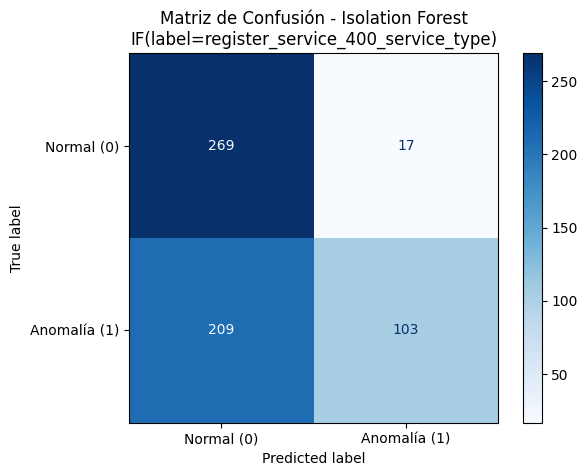

{'test_name': 'IF(label=register_service_404_no_user)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 113, 'FP': 10, 'TN': 294, 'FN': 199, 'accuracy': 0.6607142857142857, 'precision': 0.9186991869918699, 'recall': 0.36217948717948717, 'specificity': 0.9671052631578947, 'f1_score': 0.5195402298850574}


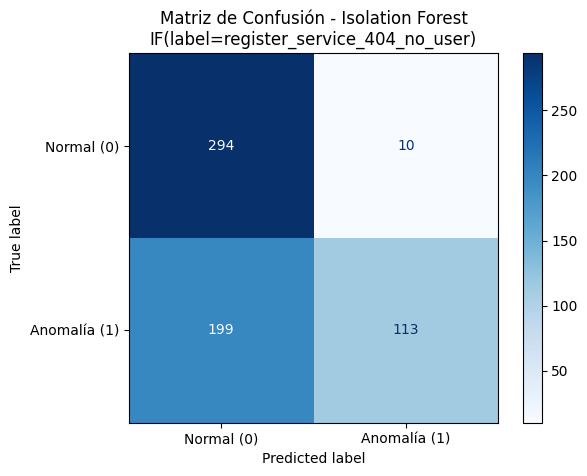

{'test_name': 'IF(label=update_service_404_user_id)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 87, 'FP': 15, 'TN': 232, 'FN': 173, 'accuracy': 0.6291913214990138, 'precision': 0.8529411764705882, 'recall': 0.3346153846153846, 'specificity': 0.9392712550607287, 'f1_score': 0.48066298342541436}


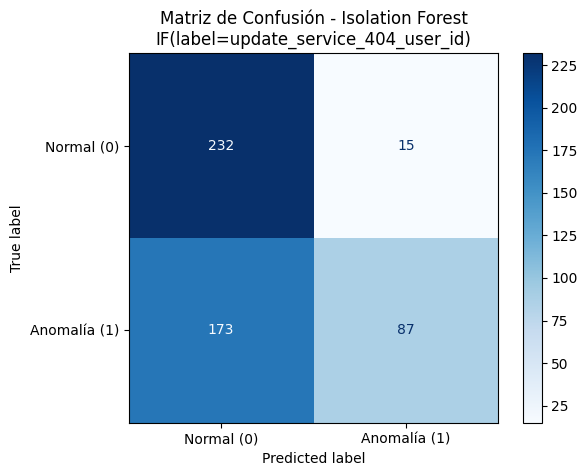

{'test_name': 'IF(label=delete_service_404_no_service)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 104, 'FP': 14, 'TN': 264, 'FN': 208, 'accuracy': 0.6237288135593221, 'precision': 0.8813559322033898, 'recall': 0.3333333333333333, 'specificity': 0.9496402877697842, 'f1_score': 0.48372093023255813}


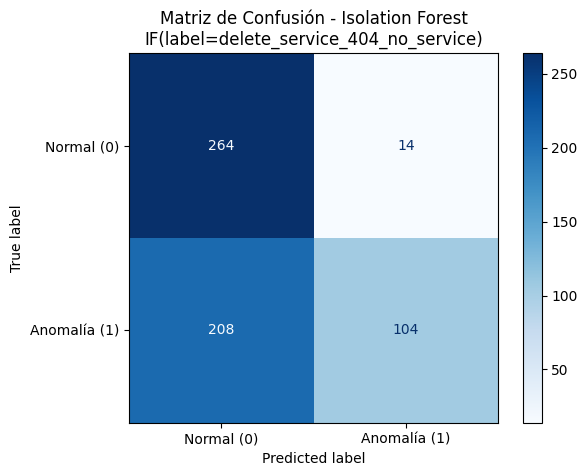

{'test_name': 'IF(label=get_service_404_no_service)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 122, 'FP': 14, 'TN': 300, 'FN': 242, 'accuracy': 0.6224188790560472, 'precision': 0.8970588235294118, 'recall': 0.33516483516483514, 'specificity': 0.9554140127388535, 'f1_score': 0.488}


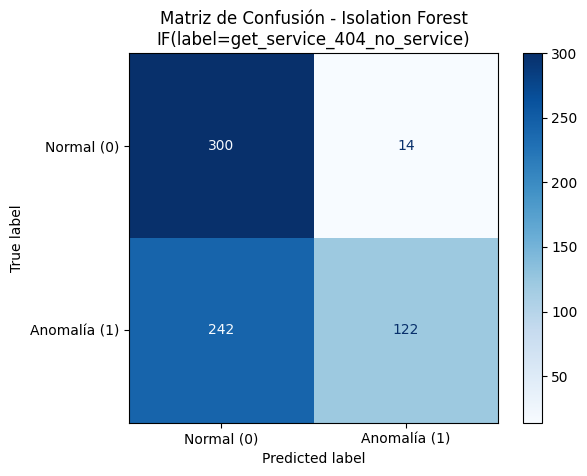

{'test_name': 'IF(label=get_service_page_400_no_page)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 117, 'FP': 19, 'TN': 298, 'FN': 247, 'accuracy': 0.6093979441997063, 'precision': 0.8602941176470589, 'recall': 0.32142857142857145, 'specificity': 0.9400630914826499, 'f1_score': 0.468}


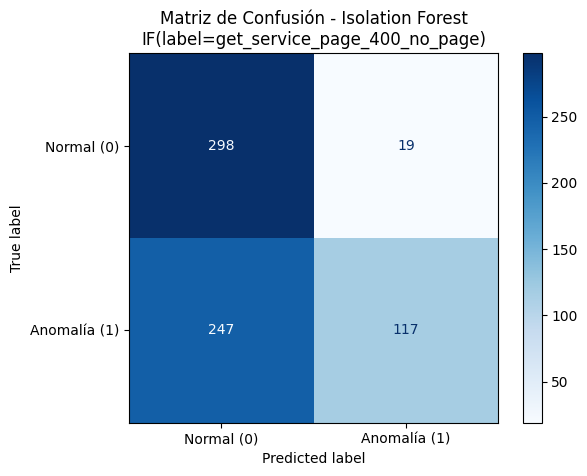

{'test_name': 'IF(label=authorization_code_invalid_password_401)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 127, 'FP': 10, 'TN': 310, 'FN': 237, 'accuracy': 0.6388888888888888, 'precision': 0.927007299270073, 'recall': 0.3489010989010989, 'specificity': 0.96875, 'f1_score': 0.5069860279441117}


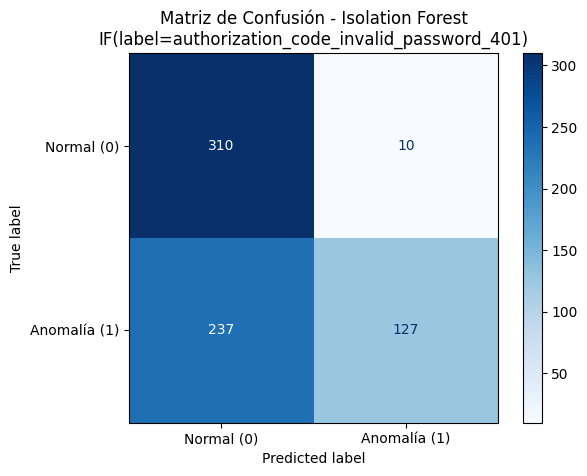

{'test_name': 'IF(label=authorization_code_missing_response_type_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 108, 'FP': 10, 'TN': 267, 'FN': 204, 'accuracy': 0.6366723259762309, 'precision': 0.9152542372881356, 'recall': 0.34615384615384615, 'specificity': 0.9638989169675091, 'f1_score': 0.5023255813953489}


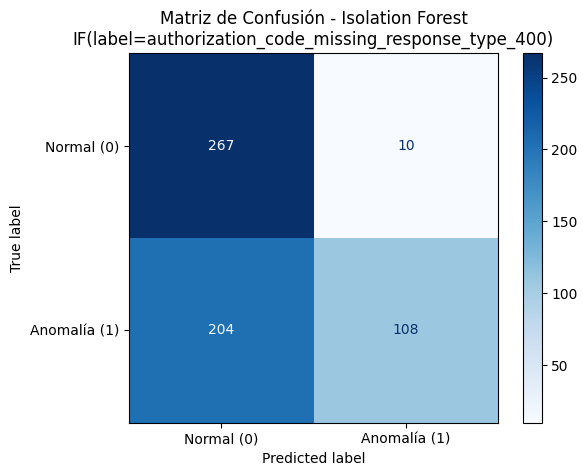

{'test_name': 'IF(label=access_token_illegal_grant_type_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 99, 'FP': 25, 'TN': 281, 'FN': 213, 'accuracy': 0.6148867313915858, 'precision': 0.7983870967741935, 'recall': 0.3173076923076923, 'specificity': 0.9183006535947712, 'f1_score': 0.4541284403669725}


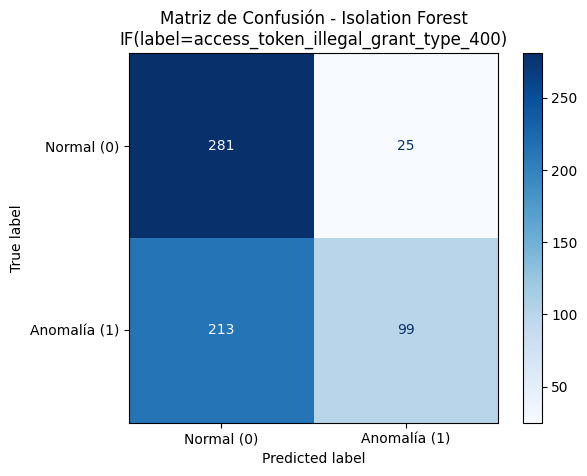

{'test_name': 'IF(label=code_challenge_too_short_pkce_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 95, 'FP': 24, 'TN': 259, 'FN': 217, 'accuracy': 0.5949579831932773, 'precision': 0.7983193277310925, 'recall': 0.30448717948717946, 'specificity': 0.9151943462897526, 'f1_score': 0.4408352668213457}


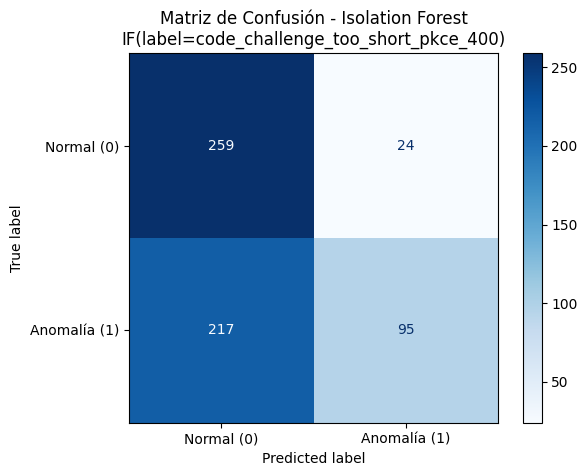

{'test_name': 'IF(label=authorization_code_invalid_client_id_404)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 102, 'FP': 20, 'TN': 279, 'FN': 210, 'accuracy': 0.6235679214402619, 'precision': 0.8360655737704918, 'recall': 0.3269230769230769, 'specificity': 0.9331103678929766, 'f1_score': 0.4700460829493088}


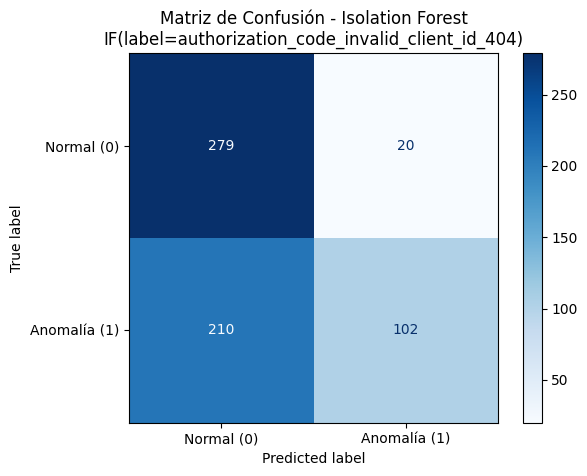

{'test_name': 'IF(label=access_token_client_id_not_found_404)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 103, 'FP': 21, 'TN': 286, 'FN': 209, 'accuracy': 0.6284329563812601, 'precision': 0.8306451612903226, 'recall': 0.3301282051282051, 'specificity': 0.9315960912052117, 'f1_score': 0.4724770642201835}


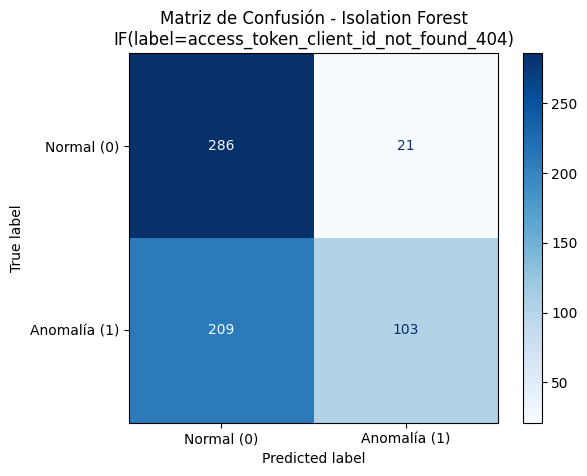

{'test_name': 'IF(label=access_token_auth_header_error_401)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 96, 'FP': 25, 'TN': 265, 'FN': 216, 'accuracy': 0.5996677740863787, 'precision': 0.7933884297520661, 'recall': 0.3076923076923077, 'specificity': 0.9137931034482759, 'f1_score': 0.44341801385681295}


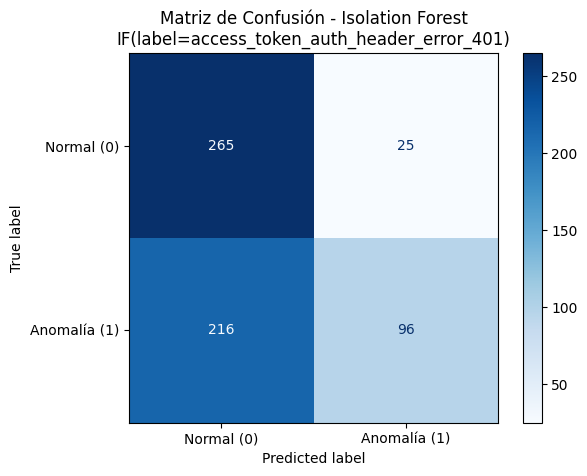

{'test_name': 'IF(label=access_token_form_urlencoded_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 100, 'FP': 25, 'TN': 285, 'FN': 212, 'accuracy': 0.6189710610932476, 'precision': 0.8, 'recall': 0.32051282051282054, 'specificity': 0.9193548387096774, 'f1_score': 0.4576659038901602}


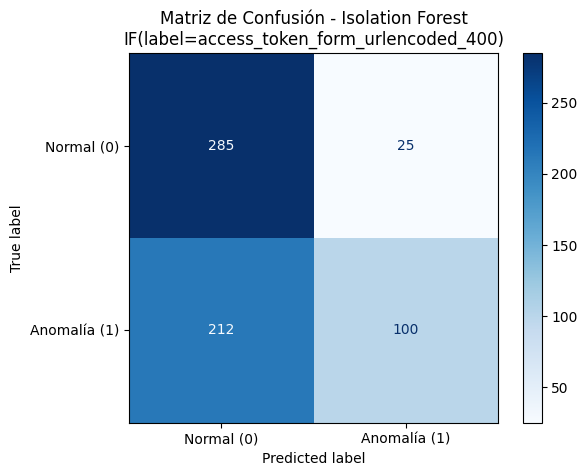

{'test_name': 'IF(label=access_token_authorization_form_401)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 98, 'FP': 24, 'TN': 273, 'FN': 214, 'accuracy': 0.6091954022988506, 'precision': 0.8032786885245902, 'recall': 0.3141025641025641, 'specificity': 0.9191919191919192, 'f1_score': 0.45161290322580644}


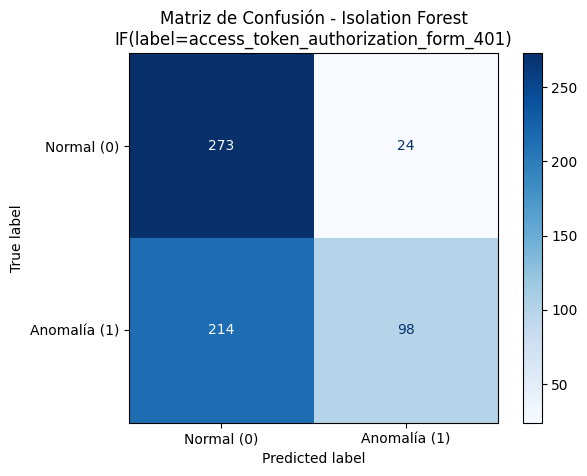

{'test_name': 'IF(label=invalid_code_challenge_method_pkce_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 95, 'FP': 25, 'TN': 261, 'FN': 217, 'accuracy': 0.5953177257525084, 'precision': 0.7916666666666666, 'recall': 0.30448717948717946, 'specificity': 0.9125874125874126, 'f1_score': 0.4398148148148148}


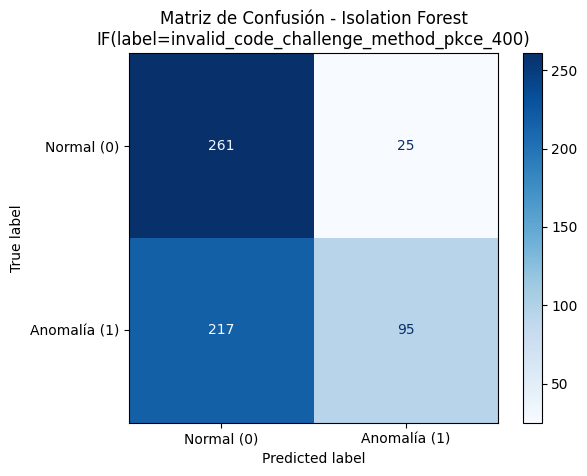

{'test_name': 'IF(label=code_challenge_too_long_pkce_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 99, 'FP': 19, 'TN': 257, 'FN': 213, 'accuracy': 0.6054421768707483, 'precision': 0.8389830508474576, 'recall': 0.3173076923076923, 'specificity': 0.9311594202898551, 'f1_score': 0.4604651162790698}


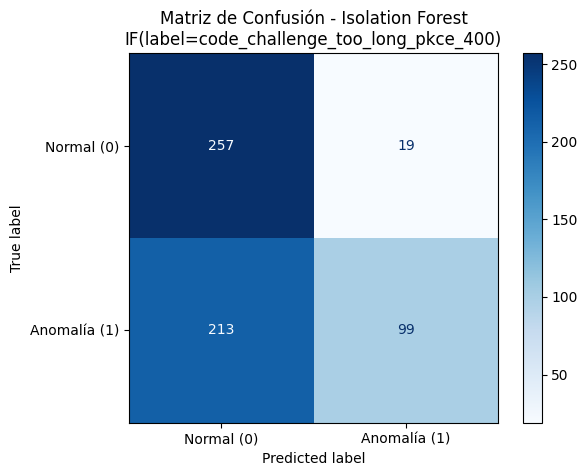

{'test_name': 'IF(label=code_verifier_too_short_pkce_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 81, 'FP': 36, 'TN': 235, 'FN': 231, 'accuracy': 0.5420240137221269, 'precision': 0.6923076923076923, 'recall': 0.25961538461538464, 'specificity': 0.8671586715867159, 'f1_score': 0.3776223776223776}


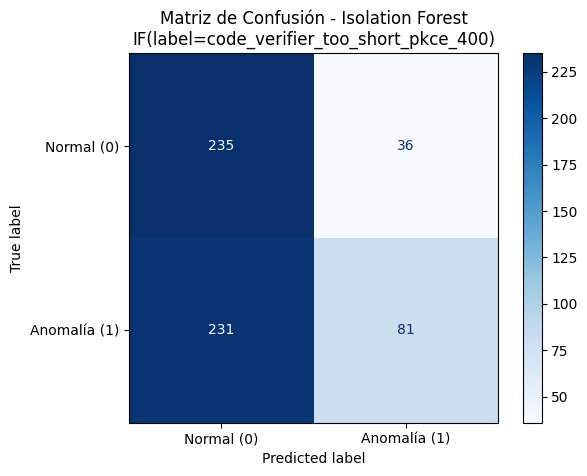

{'test_name': 'IF(label=get_token_404)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 90, 'FP': 30, 'TN': 255, 'FN': 222, 'accuracy': 0.5778894472361809, 'precision': 0.75, 'recall': 0.28846153846153844, 'specificity': 0.8947368421052632, 'f1_score': 0.4166666666666667}


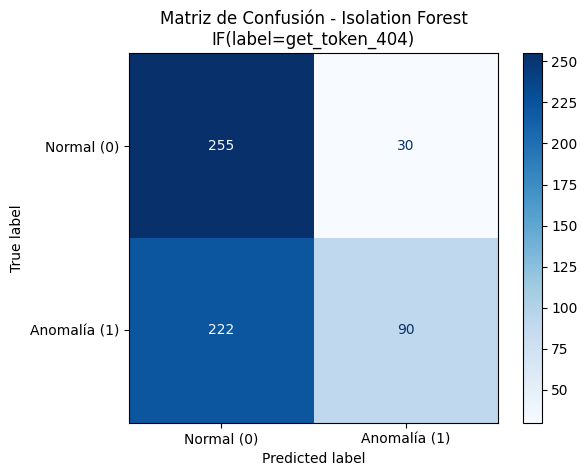

{'test_name': 'IF(label=delete_token_404)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 88, 'FP': 28, 'TN': 241, 'FN': 224, 'accuracy': 0.5662650602409639, 'precision': 0.7586206896551724, 'recall': 0.28205128205128205, 'specificity': 0.895910780669145, 'f1_score': 0.411214953271028}


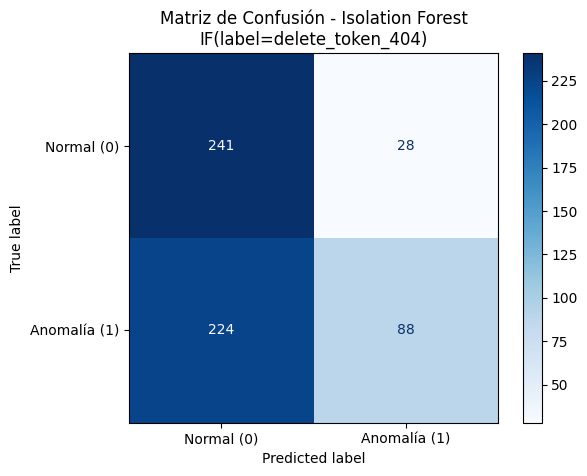

{'test_name': 'IF(label=get_token_page_400_no_page)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 86, 'FP': 30, 'TN': 236, 'FN': 226, 'accuracy': 0.5570934256055363, 'precision': 0.7413793103448276, 'recall': 0.27564102564102566, 'specificity': 0.8872180451127819, 'f1_score': 0.40186915887850466}


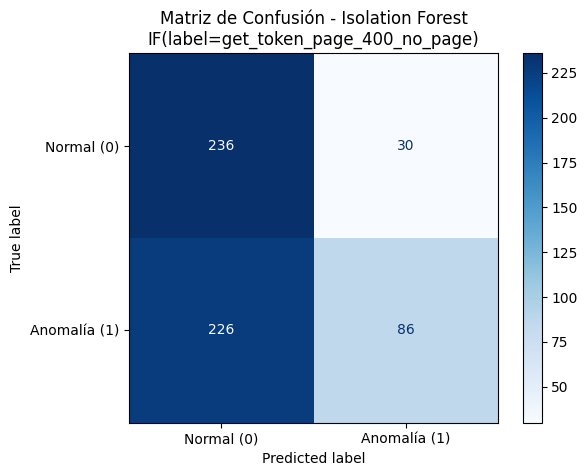

{'test_name': 'IF(label=register_user_400_user_exists)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 94, 'FP': 25, 'TN': 255, 'FN': 218, 'accuracy': 0.589527027027027, 'precision': 0.7899159663865546, 'recall': 0.30128205128205127, 'specificity': 0.9107142857142857, 'f1_score': 0.4361948955916473}


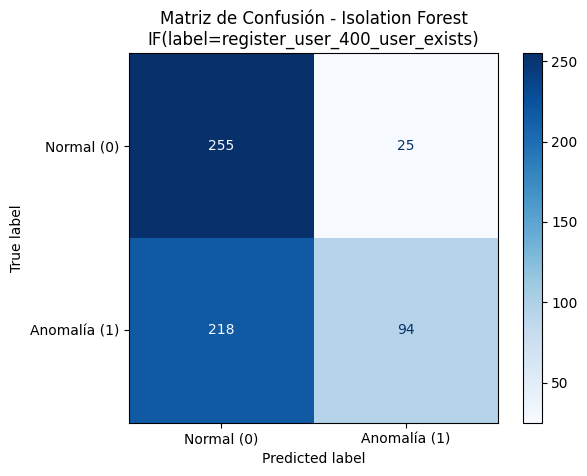

{'test_name': 'IF(label=register_user_400_email_exists)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 85, 'FP': 35, 'TN': 251, 'FN': 227, 'accuracy': 0.5618729096989966, 'precision': 0.7083333333333334, 'recall': 0.2724358974358974, 'specificity': 0.8776223776223776, 'f1_score': 0.39351851851851855}


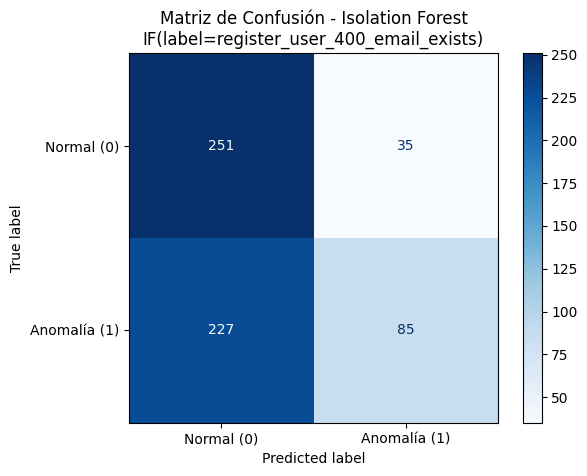

{'test_name': 'IF(label=register_user_400_password_no_match)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 82, 'FP': 39, 'TN': 255, 'FN': 230, 'accuracy': 0.5561056105610561, 'precision': 0.6776859504132231, 'recall': 0.26282051282051283, 'specificity': 0.8673469387755102, 'f1_score': 0.3787528868360277}


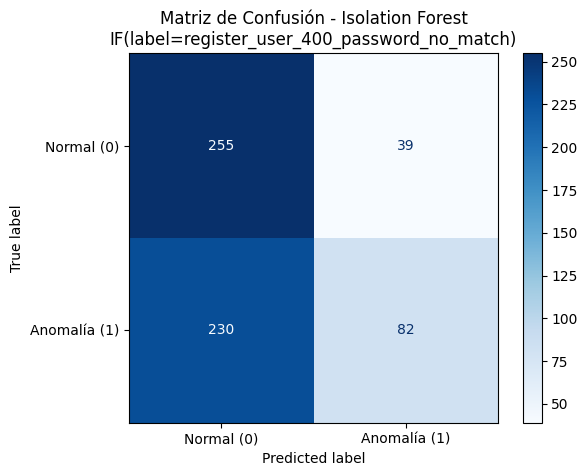

{'test_name': 'IF(label=access_token_missing_authorization_header_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 100, 'FP': 22, 'TN': 277, 'FN': 212, 'accuracy': 0.6170212765957447, 'precision': 0.819672131147541, 'recall': 0.32051282051282054, 'specificity': 0.9264214046822743, 'f1_score': 0.4608294930875576}


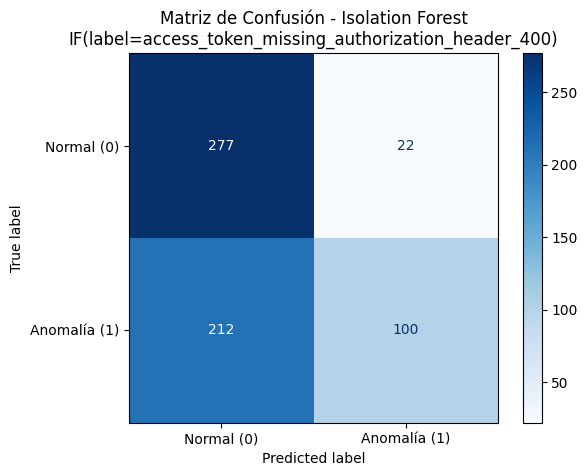

{'test_name': 'IF(label=get_user_page_400_no_page)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 89, 'FP': 31, 'TN': 256, 'FN': 223, 'accuracy': 0.5759599332220368, 'precision': 0.7416666666666667, 'recall': 0.28525641025641024, 'specificity': 0.89198606271777, 'f1_score': 0.41203703703703703}


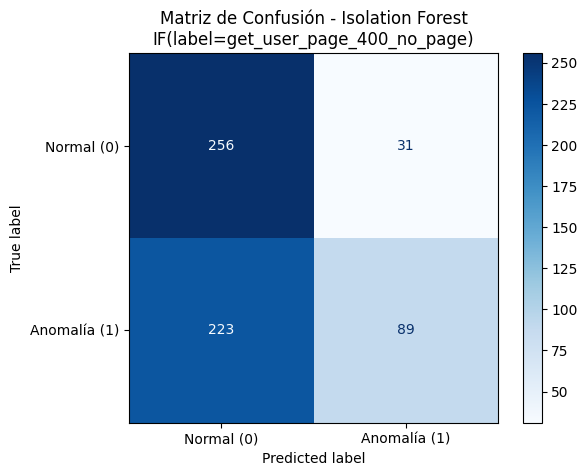

{'test_name': 'IF(label=delete_user_404_no_user)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 83, 'FP': 36, 'TN': 247, 'FN': 229, 'accuracy': 0.5546218487394958, 'precision': 0.6974789915966386, 'recall': 0.266025641025641, 'specificity': 0.872791519434629, 'f1_score': 0.3851508120649652}


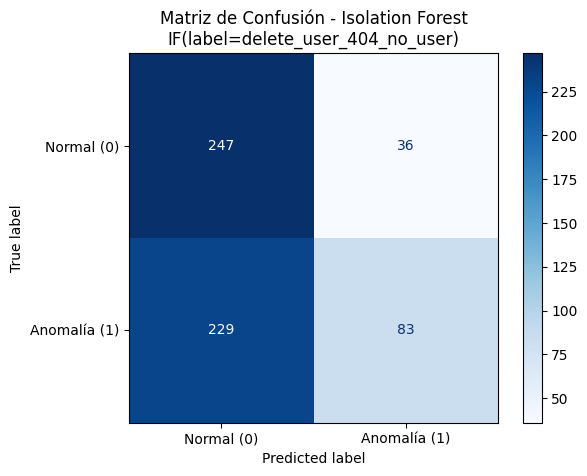

{'test_name': 'IF(label=register_service_400_service_id)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 69, 'FP': 7, 'TN': 166, 'FN': 139, 'accuracy': 0.6167979002624672, 'precision': 0.9078947368421053, 'recall': 0.3317307692307692, 'specificity': 0.9595375722543352, 'f1_score': 0.4859154929577465}


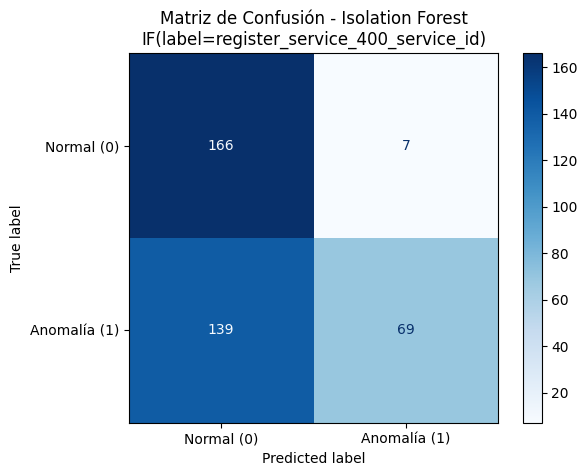

{'test_name': 'IF(label=update_service_404_service_id)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 83, 'FP': 17, 'TN': 224, 'FN': 177, 'accuracy': 0.6127744510978044, 'precision': 0.83, 'recall': 0.3192307692307692, 'specificity': 0.9294605809128631, 'f1_score': 0.46111111111111114}


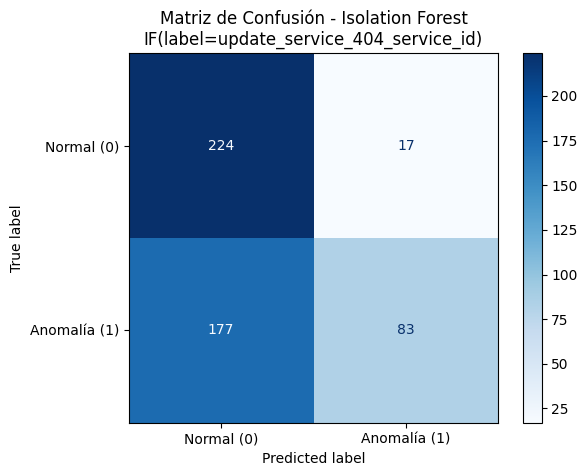

{'test_name': 'IF(label=authorization_code_response_not_code_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 95, 'FP': 20, 'TN': 243, 'FN': 217, 'accuracy': 0.5878260869565217, 'precision': 0.8260869565217391, 'recall': 0.30448717948717946, 'specificity': 0.9239543726235742, 'f1_score': 0.4449648711943794}


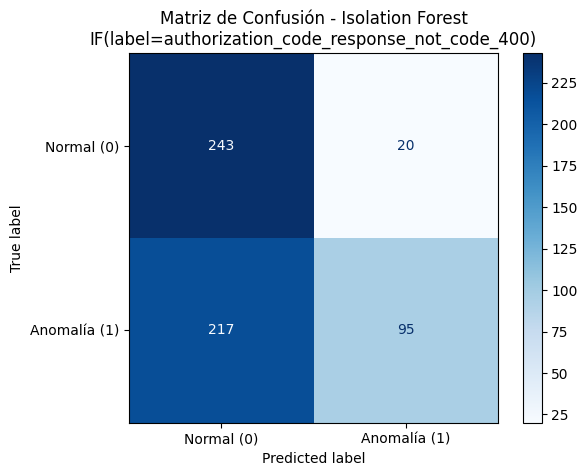

{'test_name': 'IF(label=code_challenge_invalid_format_pkce_400)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 93, 'FP': 23, 'TN': 243, 'FN': 219, 'accuracy': 0.5813148788927336, 'precision': 0.8017241379310345, 'recall': 0.2980769230769231, 'specificity': 0.9135338345864662, 'f1_score': 0.43457943925233644}


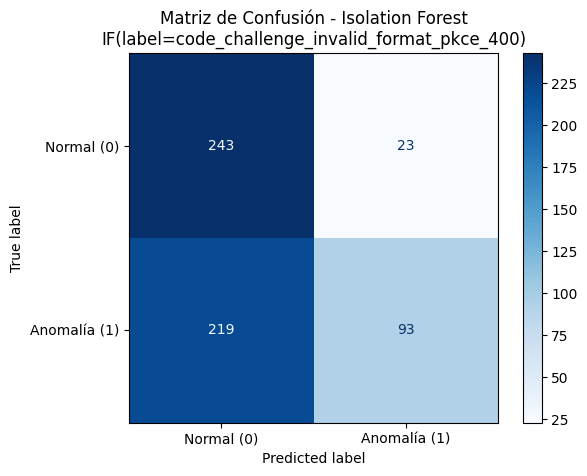

{'test_name': 'IF(label=register_user_400_no_password)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 85, 'FP': 37, 'TN': 262, 'FN': 227, 'accuracy': 0.5679214402618658, 'precision': 0.6967213114754098, 'recall': 0.2724358974358974, 'specificity': 0.8762541806020067, 'f1_score': 0.391705069124424}


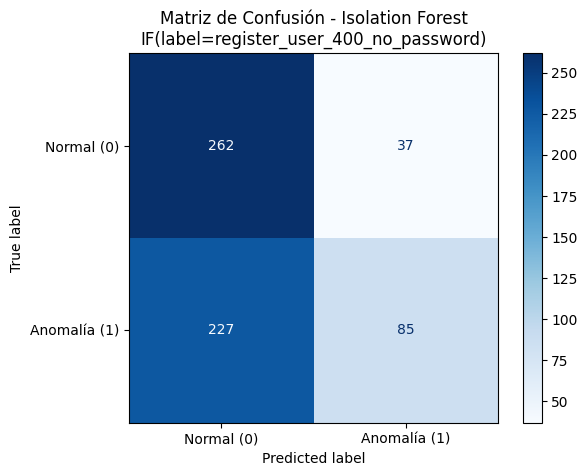

{'test_name': 'IF(label=update_password_401_wrong_password)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 80, 'FP': 35, 'TN': 229, 'FN': 232, 'accuracy': 0.5364583333333334, 'precision': 0.6956521739130435, 'recall': 0.2564102564102564, 'specificity': 0.8674242424242424, 'f1_score': 0.3747072599531616}


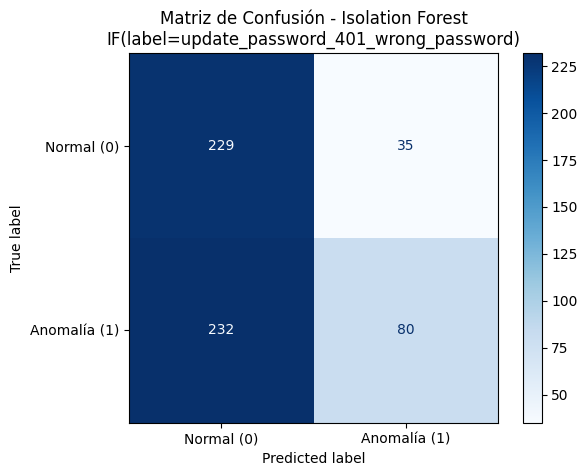

{'test_name': 'IF(label=register_client_400_clientProfile)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 18, 'FP': 1, 'TN': 41, 'FN': 34, 'accuracy': 0.6276595744680851, 'precision': 0.9473684210526315, 'recall': 0.34615384615384615, 'specificity': 0.9761904761904762, 'f1_score': 0.5070422535211268}


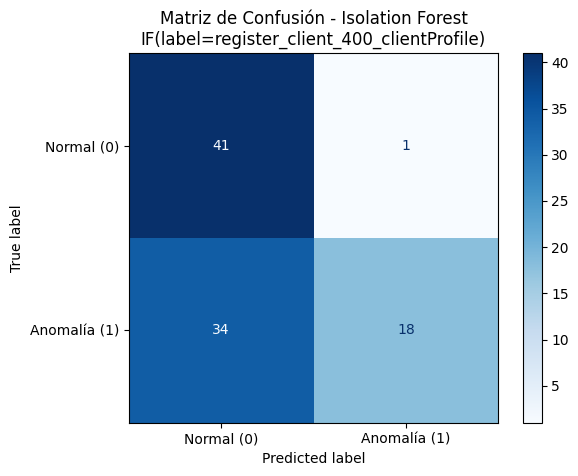

{'test_name': 'IF(label=update_client_404_clientId)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 59, 'FP': 2, 'TN': 146, 'FN': 97, 'accuracy': 0.6743421052631579, 'precision': 0.9672131147540983, 'recall': 0.3782051282051282, 'specificity': 0.9864864864864865, 'f1_score': 0.543778801843318}


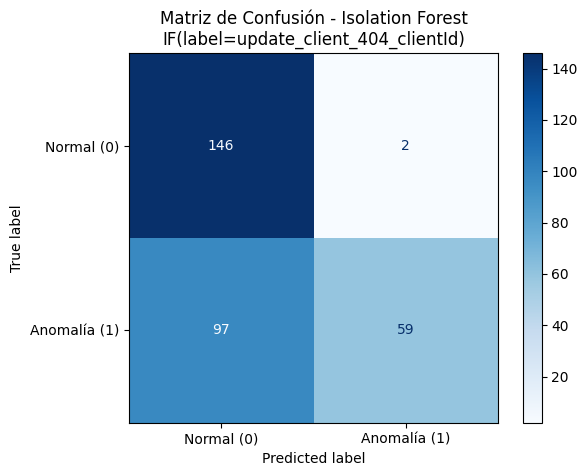

{'test_name': 'IF(label=update_client_400_clientType)', 'parametros': '{"contaminacion": 0.0005}', 'TP': 33, 'FP': 1, 'TN': 64, 'FN': 71, 'accuracy': 0.5739644970414202, 'precision': 0.9705882352941176, 'recall': 0.3173076923076923, 'specificity': 0.9846153846153847, 'f1_score': 0.4782608695652174}


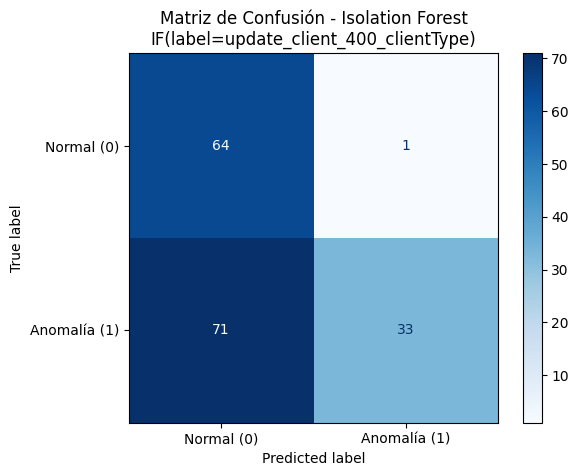

In [97]:
lista_result=[]
ontaminacion=0.001
dic_model={}
for label in lista_label:
    if label=='correct':
        continue
    idx_train = dic_idx_train[label]
    X_train   = X_matrix[idx_train]
 
    dic_model[label] = IsolationForest(
        n_estimators=200, 
        max_samples='auto', 
        contamination=contaminacion, 
        random_state=SEED
    )
    N_datos_test_por_anomalia = int( len(dic_idx_test[label])  / (len(lista_label)-2) )+1
    idx_test = np.array([], dtype=int)
    idx_test_tmp = np.array([], dtype=int)
    for label2 in lista_label:
        # print('=====')
        # print(label2)
        if label2=='correct':
            continue
        elif label2==label:
            idx_test_tmp=dic_idx_test[label2]
        else:
            idx_test_tmp=dic_idx_test[label2][:N_datos_test_por_anomalia]
        # print(len(idx_test_tmp))
            
        idx_test=np.concatenate((idx_test, idx_test_tmp))
        
    X_test   = X_matrix[idx_test]
    dic_model[label].fit(X_train)
    Y_pred = dic_model[label].predict(X_test)
    scores = dic_model[label].decision_function(X_test)
    threshold = np.percentile(scores, 20)
    y_pred = np.where(scores < threshold, 1, 0)


    y_true = df.loc[idx_test, 'label'].apply(lambda x: 0 if x == label else 1)
    #y_pred = np.where(Y_pred == 1, 0, 1)

   # 1. Componentes de la matriz de confusión (con anomalía = positivo = 1)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # 2. Cálculo de métricas
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)         # Sensibilidad / True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0          # True Negative Rate
    f1 = f1_score(y_true, y_pred, zero_division=0)

    model_name=f'IF(label={label})'
    parametros={'contaminacion':contaminacion}
    # 3. Guardar en un diccionario de registro
    reg_resultado_algoritmo = {

        'test_name': model_name,
        'parametros': json.dumps(parametros),
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1)
    }
    lista_result.append(reg_resultado_algoritmo)
    print(reg_resultado_algoritmo)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión - Isolation Forest\n{model_name}')
    plt.show()


df_anomaly_detection_summary = pd.DataFrame(lista_result)

In [98]:
df_anomaly_detection_summary

,test_name,parametros,TP,FP,TN,FN,accuracy,precision,recall,specificity,f1_score
0,IF(label=invalid_code_verifier_format_PKCE_400),"{""contaminacion"": 0.0005}",79,39,236,233,0.536627,0.669492,0.253205,0.858182,0.367442
1,IF(label=code_verifier_too_long_pkce_400),"{""contaminacion"": 0.0005}",87,28,233,225,0.558464,0.756522,0.278846,0.892720,0.407494
2,IF(label=code_verifier_missing_pkce_400),"{""contaminacion"": 0.0005}",94,23,250,218,0.588034,0.803419,0.301282,0.915751,0.438228
3,IF(label=verification_failed_pkce_400),"{""contaminacion"": 0.0005}",87,34,256,225,0.569767,0.719008,0.278846,0.882759,0.401848
4,IF(label=authorization_code_client_id_missing_...,"{""contaminacion"": 0.0005}",94,25,257,218,0.590909,0.789916,0.301282,0.911348,0.436195
5,IF(label=update_user_404_no_user),"{""contaminacion"": 0.0005}",96,23,257,216,0.596284,0.806723,0.307692,0.917857,0.445476
6,IF(label=update_password_404_user_not_found),"{""contaminacion"": 0.0005}",71,44,216,241,0.501748,0.617391,0.227564,0.830769,0.332553
7,IF(label=update_password_400_not_match),"{""contaminacion"": 0.0005}",203,20,522,369,0.650808,0.910314,0.354895,0.963100,0.510692
8,IF(label=access_token_client_secret_wrong_401),"{""contaminacion"": 0.0005}",98,22,265,214,0.606010,0.816667,0.314103,0.923345,0.453704
9,IF(label=register_client_400_clientType),"{""contaminacion"": 0.0005}",123,0,302,189,0.692182,1.000000,0.394231,1.000000,0.565517


In [63]:
len(dic_idx_test[label])

275

In [67]:
len(idx_train)

823